In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from pangya_physics import CLUBS, Wind, find_power as find_power_binary
from pangya_physics.smart_calc_solver import find_power as find_power_smart_style

In [2]:
club = CLUBS["1W"]
wind = Wind(speed=0, degree=0)

distances = [50, 100, 150, 200, 250, 300]

In [3]:
results = []

for distance in distances:
    binary = find_power_binary(
        club=club,
        wind=wind,
        target_distance=distance,
        target_height=0,
    )

    smart_style = find_power_smart_style(
        club=club,
        wind=wind,
        target_distance=distance,
        target_height=0,
    )

    results.append({
        "Distância Alvo": distance,
        "Solver": "Binary Search",
        "Power %": round(binary.power_percent * 100, 2),
        "Distância Final": round(binary.final_distance, 2),
        "Erro": round(binary.error, 2),
        "Iterações": binary.iterations,
        "Encontrado": binary.found,
    })

    results.append({
        "Distância Alvo": distance,
        "Solver": "Smart Style Feed",
        "Power %": round(smart_style.power_percent * 100, 2),
        "Distância Final": round(smart_style.final_distance, 2),
        "Erro": round(smart_style.error, 2),
        "Iterações": smart_style.iterations,
        "Encontrado": smart_style.found,
    })

df_compare = pd.DataFrame(results)
df_compare

,Distância Alvo,Solver,Power %,Distância Final,Erro,Iterações,Encontrado
0,50,Binary Search,24.41,50.00,0.00,10,True
1,50,Smart Style Feed,24.44,50.04,-0.04,46,True
2,100,Binary Search,35.45,99.14,0.86,60,False
3,100,Smart Style Feed,35.45,99.14,0.86,1000,False
4,150,Binary Search,44.75,150.03,-0.03,14,True
5,150,Smart Style Feed,44.76,150.05,-0.05,40,True
6,200,Binary Search,53.45,200.02,-0.02,12,True
7,200,Smart Style Feed,53.44,199.99,0.01,33,True
8,250,Binary Search,61.98,250.88,-0.88,60,False
9,250,Smart Style Feed,61.98,249.15,0.85,1000,False


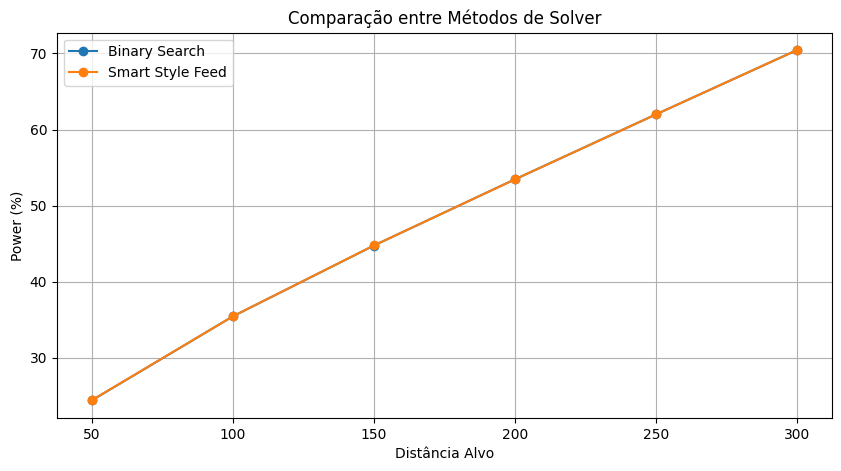

In [4]:
plt.figure(figsize=(10, 5))

for solver in df_compare["Solver"].unique():
    subset = df_compare[df_compare["Solver"] == solver]

    plt.plot(
        subset["Distância Alvo"],
        subset["Power %"],
        marker="o",
        label=solver,
    )

plt.xlabel("Distância Alvo")
plt.ylabel("Power (%)")
plt.title("Comparação entre Métodos de Solver")
plt.grid(True)
plt.legend()
plt.show()